In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy as sp
from skimage import io
from skimage.color import rgb2hsv, hsv2rgb

gamma = 2.2
Z_min = 0.02
Z_max = 0.95
t = 1/2048

In [2]:
im_list = [io.imread(f'data/door_stack/exposure{i}.tiff').astype(np.float32)/65535 for i in range(1,17)]

In [3]:
im = im_list[10]

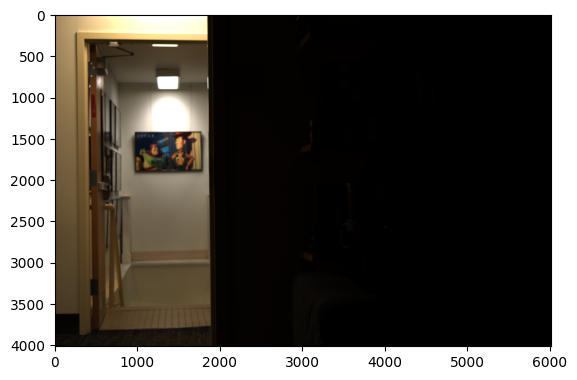

In [4]:
plt.imshow(im_list[10])

In [5]:
def w_uniform(z):
  return np.logical_and(Z_min <= z, z<= Z_max)


In [6]:
t_list = np.array([t*2**k for k in range(16)])
t_list

array([4.8828125e-04, 9.7656250e-04, 1.9531250e-03, 3.9062500e-03,
       7.8125000e-03, 1.5625000e-02, 3.1250000e-02, 6.2500000e-02,
       1.2500000e-01, 2.5000000e-01, 5.0000000e-01, 1.0000000e+00,
       2.0000000e+00, 4.0000000e+00, 8.0000000e+00, 1.6000000e+01])

In [7]:
sum_nominator = np.zeros_like(im)
sum_denominator = np.ones_like(sum_nominator) * 0.001

In [8]:
for i in range(16):
  sum_nominator += w_uniform(im_list[i])*im_list[i]/(t_list[i])
  sum_denominator += w_uniform(im_list[i])

In [9]:
final_picture = sum_nominator / sum_denominator

In [10]:
final_picture.max()

np.float32(35.33547)

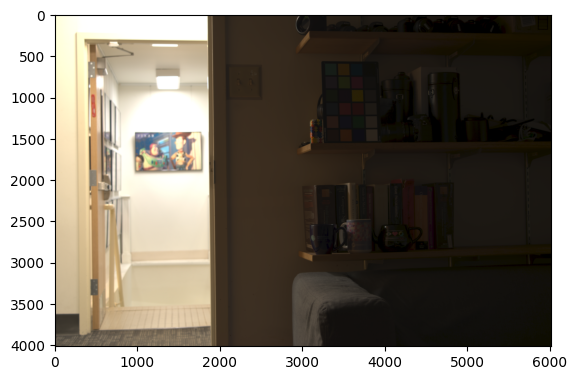

In [11]:
plt.imshow(final_picture ** (1/gamma))